In [1]:
import pandas as pd
import numpy as np
import os
import re
import warnings
warnings.filterwarnings('ignore')

BASE_DIR   =os.path.dirname(os.getcwd())
DATA_DIR   = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = DATA_DIR   

CALENDAR_PATH = os.path.join(DATA_DIR, 'calendar', 'calendar.csv')
LISTINGS_PATH = os.path.join(DATA_DIR, 'listings', 'listings.csv')
OUTPUT_PATH   = os.path.join(OUTPUT_DIR, 'processed_data.csv')

print('calendar :', CALENDAR_PATH)
print('listings :', LISTINGS_PATH)
print('output   :', OUTPUT_PATH)

calendar : d:\School\msba\作业\5113\group\sg\data\calendar\calendar.csv
listings : d:\School\msba\作业\5113\group\sg\data\listings\listings.csv
output   : d:\School\msba\作业\5113\group\sg\data\processed_data.csv


## 1. read raw data

In [2]:
cal = pd.read_csv(CALENDAR_PATH, low_memory=False)
lst = pd.read_csv(LISTINGS_PATH, low_memory=False)

print(f'calendar : {cal.shape[0]:,} rows × {cal.shape[1]} columns')
print(f'listings : {lst.shape[0]:,} rows × {lst.shape[1]} columns')
cal.head(3)

calendar : 1,347,945 rows × 7 columns
listings : 3,693 rows × 79 columns


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,12434512,2025-09-28,f,NaN,NaN,90,1125
1,12434512,2025-09-29,f,NaN,NaN,90,1125
2,12434512,2025-09-30,f,NaN,NaN,90,1125


## 2. clean calendar.csv

In [3]:
cal['booked'] = (cal['available'] == 'f').astype(int)

cal['date'] = pd.to_datetime(cal['date'])

def parse_price(s):
   
    if pd.isna(s) or str(s).strip() == '':
        return np.nan
    return float(re.sub(r'[\$,]', '', str(s)))

cal['price_cal']          = cal['price'].apply(parse_price)
cal['adjusted_price_cal'] = cal['adjusted_price'].apply(parse_price)


cal_clean = cal[[
    'listing_id', 'date', 
    
    'booked'
]].copy()

cal_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1347945 entries, 0 to 1347944
Data columns (total 3 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   listing_id  1347945 non-null  int64         
 1   date        1347945 non-null  datetime64[ns]
 2   booked      1347945 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 30.9 MB


## 3. clean listings.csv

In [4]:
DROP_COLS = [
    'listing_url', 'scrape_id', 'source', 'name', 'description',
    'neighborhood_overview', 'picture_url',
    'host_url', 'host_name', 'host_thumbnail_url', 'host_picture_url',
    'host_about', 'host_neighbourhood', 'host_verifications',
    'neighbourhood',           
    'amenities',               
    'bathrooms',               
    'calendar_updated',        
    'license',                 
    'calendar_last_scraped',   
]

lst_clean = lst.drop(columns=[c for c in DROP_COLS if c in lst.columns]).copy()
print(f'keep {lst_clean.shape[1]} columns (original: {lst.shape[1]} columns)')

keep 59 columns (original: 79 columns)


In [5]:
for col in ['last_scraped', 'host_since', 'first_review', 'last_review']:
    lst_clean[col] = pd.to_datetime(lst_clean[col], errors='coerce')

for col in ['host_response_rate', 'host_acceptance_rate']:
    lst_clean[col] = (
        lst_clean[col]
        .str.replace('%', '', regex=False)
        .apply(pd.to_numeric, errors='coerce') / 100
    )

BOOL_COLS = ['host_is_superhost', 'host_has_profile_pic',
             'host_identity_verified', 'has_availability', 'instant_bookable']
for col in BOOL_COLS:
    if col in lst_clean.columns:
        lst_clean[col] = lst_clean[col].map({'t': 1, 'f': 0})

lst_clean['price_listing'] = lst_clean['price'].apply(parse_price)
lst_clean.drop(columns=['price'], inplace=True)

_before = lst_clean.shape[0]
lst_clean = lst_clean.dropna(subset=['price_listing']).copy()
print(f'listings delete price empty/NaN：{_before:,} → {lst_clean.shape[0]:,} rows（deleted {_before - lst_clean.shape[0]:,} rows）')

lst_clean['bathrooms_num'] = (
    lst_clean['bathrooms_text']
    .str.extract(r'([\d\.]+)')[0]
    .apply(pd.to_numeric, errors='coerce')
)
lst_clean.drop(columns=['bathrooms_text'], inplace=True)

if 'estimated_revenue_l365d' in lst_clean.columns:
    lst_clean['estimated_revenue_l365d'] = lst_clean['estimated_revenue_l365d'].apply(parse_price)

lst_clean.head(2)

listings delete price empty/NaN：3,693 → 2,643 rows（deleted 1,050 rows）


,id,last_scraped,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_listing,bathrooms_num
1,71896,2025-09-28,367042,2011-01-29,Singapore,within a few hours,1.0,1.0,0.0,5,...,4.17,4.04,0,5,0,5,0,0.14,104.0,NaN
2,71903,2025-09-28,367042,2011-01-29,Singapore,within a few hours,1.0,1.0,0.0,5,...,4.50,4.36,0,5,0,5,0,0.26,76.0,NaN


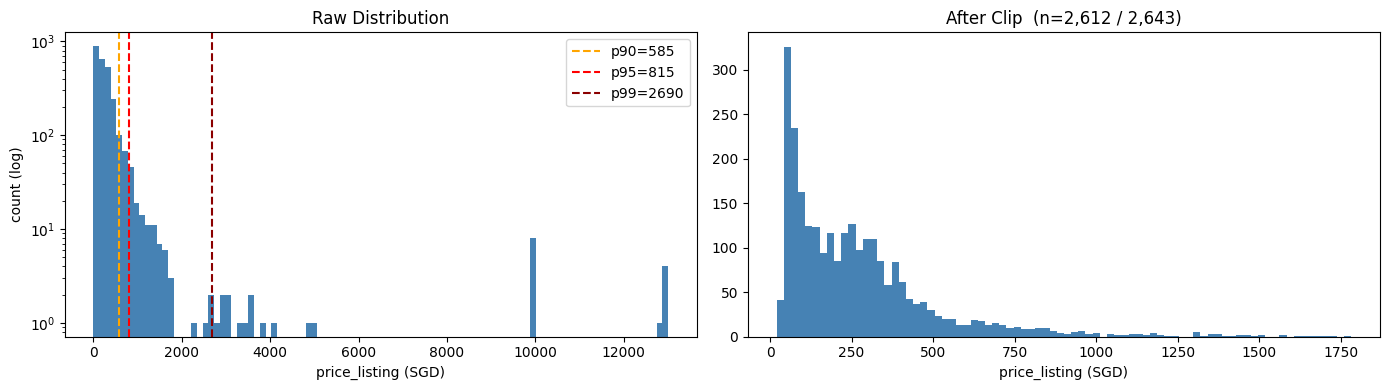

listings delete outliers：2643 → 2612 rows（deleted 31 rows）
price_tier distribution:
price_tier
Budget(≤100)          725
Standard(101-300)    1014
Premium(301-600)      648
Luxury(601-2000)      225
Name: count, dtype: Int64


In [6]:
import matplotlib.pyplot as plt

p = lst_clean['price_listing'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(p, bins=100, color='steelblue', edgecolor='none')
axes[0].set_yscale('log')
axes[0].set_xlabel('price_listing (SGD)')
axes[0].set_ylabel('count (log)')
axes[0].set_title('Raw Distribution')
for q, c in [(0.90, 'orange'), (0.95, 'red'), (0.99, 'darkred')]:
    v = p.quantile(q)
    axes[0].axvline(v, color=c, linestyle='--', label=f'p{int(q*100)}={v:.0f}')
axes[0].legend()

p_clean = p[(p >= 10) & (p <= 2000)]
axes[1].hist(p_clean, bins=80, color='steelblue', edgecolor='none')
axes[1].set_xlabel('price_listing (SGD)')
axes[1].set_title(f'After Clip  (n={len(p_clean):,} / {len(p):,})')

plt.tight_layout()
plt.show()

before = len(lst_clean)
lst_clean = lst_clean[
    ~((lst_clean['price_listing'] < 10) | (lst_clean['price_listing'] > 2000))
].copy()
print(f'listings delete outliers：{before} → {len(lst_clean)} rows（deleted {before - len(lst_clean)} rows）')

# （0=Budget ≤100 / 1=Standard 101–300 / 2=Premium 301–600 / 3=Luxury 601–2000）
bins   = [0, 100, 300, 600, 2000]
labels = [0, 1, 2, 3]
lst_clean['price_tier'] = pd.cut(
    lst_clean['price_listing'], bins=bins, labels=labels
).astype('Int64')

print('price_tier distribution:')
print(lst_clean['price_tier'].value_counts().sort_index()
      .rename({0:'Budget(≤100)', 1:'Standard(101-300)',
               2:'Premium(301-600)', 3:'Luxury(601-2000)'}))

In [7]:
before_cal = cal_clean.shape[0]
df = cal_clean.merge(
    lst_clean,
    left_on='listing_id',
    right_on='id',
    how='inner'
)
df.drop(columns=['id'], inplace=True)
print(f'calendar original rows：{before_cal:,}')
print(f'join：{before_cal:,} → {df.shape[0]:,} rows（deleted {before_cal - df.shape[0]:,} rows）')
print(f'shape：{df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

calendar original rows：1,347,945
join：1,347,945 → 953,380 rows（deleted 394,565 rows）
shape：953,380 rows × 62 columns


,listing_id,date,booked,last_scraped,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,...,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_listing,bathrooms_num,price_tier
0,12434512,2025-09-28,1,2025-09-28,1439258,2011-11-24,Singapore,within an hour,1.0,0.99,...,4.6,1,49,0,49,0,0.04,42.0,1.0,0
1,12434512,2025-09-29,1,2025-09-28,1439258,2011-11-24,Singapore,within an hour,1.0,0.99,...,4.6,1,49,0,49,0,0.04,42.0,1.0,0
2,12434512,2025-09-30,1,2025-09-28,1439258,2011-11-24,Singapore,within an hour,1.0,0.99,...,4.6,1,49,0,49,0,0.04,42.0,1.0,0


## 5. feature engineer

In [8]:
# ── 5-1  calendar.date ──────────────────────────────
df['day_of_week']  = df['date'].dt.dayofweek          
df['month']        = df['date'].dt.month
df['quarter']      = df['date'].dt.quarter
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['day_of_year']  = df['date'].dt.dayofyear

# ── 5-2  days_until_booking ──────────
df['days_until'] = (df['date'] - df['last_scraped']).dt.days

# ── 5-3  ──────────────────────
df['host_tenure_days'] = (df['last_scraped'] - df['host_since']).dt.days

# ── 5-4  ──────────────────────────────────────────
df['days_since_first_review'] = (df['last_scraped'] - df['first_review']).dt.days
df['days_since_last_review']  = (df['last_scraped'] - df['last_review']).dt.days


# ── 5-6  ──────────────────────────────────────────
df['availability_ratio_30']  = df['availability_30']  / 30
df['availability_ratio_60']  = df['availability_60']  / 60
df['availability_ratio_90']  = df['availability_90']  / 90
df['availability_ratio_365'] = df['availability_365'] / 365

# ── 5-7  ─────────────────────
df['min_max_nights_range'] = df['maximum_nights'] - df['minimum_nights']

# ── 5-8  ───────────────────────
df.drop(columns=['date', 'last_scraped', 'host_since',
                 'first_review', 'last_review'], inplace=True)

df['has_review'] = (df['number_of_reviews'] > 0).astype(int)

print('Final shape:', df.shape)

Final shape: (953380, 72)


## 6. One-Hot 

In [9]:
CAT_COLS_ALL = df.select_dtypes(include='object').columns.tolist()
print('剩余 object 列：')
for c in CAT_COLS_ALL:
    print(f'  {c}: {df[c].nunique()} 个唯一值，缺失率 {df[c].isna().mean():.1%}')

剩余 object 列：
  host_location: 22 个唯一值，缺失率 35.6%
  host_response_time: 4 个唯一值，缺失率 14.2%
  neighbourhood_cleansed: 40 个唯一值，缺失率 0.0%
  neighbourhood_group_cleansed: 5 个唯一值，缺失率 0.0%
  property_type: 42 个唯一值，缺失率 0.0%
  room_type: 4 个唯一值，缺失率 0.0%


In [10]:
import gc

if 'host_location' in df.columns:
    del df['host_location']
gc.collect()
print('删除后形状：', df.shape)

# ── 在编码前捕获映射关系 ──────────────────────────────────
encoding_records = []

# host_response_time 手动顺序编码（按响应速度排序）
response_order = {
    'within an hour'    : 0,
    'within a few hours': 1,
    'within a day'      : 2,
    'a few days or more': 3,
}
if 'host_response_time' in df.columns:
    for label, code in response_order.items():
        encoding_records.append({'column': 'host_response_time', 'code': code, 'label': label})
    df['host_response_time'] = (
        df['host_response_time'].map(response_order).fillna(-1).astype(int)
    )

# 其余 object 列：pd.Categorical codes（缺失 → -1，树模型可直接处理）
remaining_cat = df.select_dtypes(include='object').columns.tolist()
for c in remaining_cat:
    cat = pd.Categorical(df[c])
    for i, v in enumerate(cat.categories):
        encoding_records.append({'column': c, 'code': i, 'label': v})
    df[c] = cat.codes

print('编码后形状：', df.shape)
print('编码列：', ['host_response_time'] + remaining_cat)

删除后形状： (953380, 71)
编码后形状： (953380, 71)
编码列： ['host_response_time', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type']


## 7. missing values

In [11]:
# 缺失率统计（只显示有缺失的列）
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(f'共 {len(missing)} 列存在缺失：')
print(missing.to_string())

共 17 列存在缺失：
review_scores_value            0.485069
review_scores_location         0.485069
review_scores_cleanliness      0.484686
review_scores_checkin          0.484686
reviews_per_month              0.484686
review_scores_rating           0.484686
review_scores_accuracy         0.484686
days_since_last_review         0.484686
days_since_first_review        0.484686
review_scores_communication    0.484686
host_acceptance_rate           0.170750
host_response_rate             0.142037
bathrooms_num                  0.015314
host_is_superhost              0.012634
beds                           0.008423
has_availability               0.005360
bedrooms                       0.004211


In [12]:


# ── 丢弃缺失率 > 80% 的列 ────────────────────────────────
HIGH_MISS_THRESH = 0.80
high_miss_cols = missing[missing > HIGH_MISS_THRESH].index.tolist()
if high_miss_cols:
    print(f'丢弃缺失率 >{HIGH_MISS_THRESH:.0%} 的列：{high_miss_cols}')
    for c in high_miss_cols:
        if c in df.columns:
            del df[c]

# ── 保留 NaN，不做填充 ───────────────────────────────────
# LightGBM / XGBoost 原生支持 NaN，会自动学习缺失值的最优分裂方向
# 如果后续改用 sklearn DecisionTree / RandomForest，需改回中位数填充

# bool 列转 int（get_dummies 产生的）
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

print(f'剩余缺失值总数：{df.isnull().sum().sum()}')
print(f'数据形状：{df.shape}')


剩余缺失值总数：4963635
数据形状：(953380, 71)


## 8. save

In [13]:
# ── 精简到 ~20 个核心特征 ─────────────────────────────────────
# 删除原因分两类：
# 1. 数据泄露：availability_*/estimated_occupancy 等列编码了聚合预订率，对单日预订是循环预测
# 2. 冗余：与保留列高度相关或信息量低
KEEP_FEATURES = [
    # 时序（需求周期性）
    'days_until', 'day_of_week', 'is_weekend', 'month',
    # 位置
    'neighbourhood_group_cleansed',
    # 房源属性
    'room_type', 'accommodates', 'bedrooms', 'bathrooms_num', 'minimum_nights_x',
    # 价格（MAB 核心变量）
    'price_listing', 'price_tier',
    # 质量信号
    'review_scores_rating', 'number_of_reviews', 'has_review', 'instant_bookable',
    # 房东
    'host_tenure_days', 'host_is_superhost',
    # 目标变量 & ID
    'booked', 'listing_id',
]

df = df[[c for c in KEEP_FEATURES if c in df.columns]].copy()
print(f'精简后形状：{df.shape}')
print(f'保留特征：{[c for c in df.columns if c not in ["booked","listing_id"]]}')

精简后形状：(953380, 19)
保留特征：['days_until', 'day_of_week', 'is_weekend', 'month', 'neighbourhood_group_cleansed', 'room_type', 'accommodates', 'bedrooms', 'bathrooms_num', 'price_listing', 'price_tier', 'review_scores_rating', 'number_of_reviews', 'has_review', 'instant_bookable', 'host_tenure_days', 'host_is_superhost']


In [14]:
# 确认目标变量分布
print('目标变量 booked 分布：')
print(df['booked'].value_counts())
print(f'预订率：{df["booked"].mean():.2%}')

# 最终数据概览
print(f'\n最终数据集形状：{df.shape}')
df.dtypes.value_counts()

目标变量 booked 分布：
booked
0    791310
1    162070
Name: count, dtype: int64
预订率：17.00%

最终数据集形状：(953380, 19)


int64      9
float64    5
int32      2
int8       2
Int64      1
Name: count, dtype: int64

In [15]:
# 保存处理后的数据集
df.to_csv(OUTPUT_PATH, index=False)
print(f'已保存至：{OUTPUT_PATH}')
print(f'文件大小：{os.path.getsize(OUTPUT_PATH) / 1e6:.1f} MB')

已保存至：d:\School\msba\作业\5113\group\sg\data\processed_data.csv
文件大小：64.0 MB


In [16]:
# 展示前几行供核查
df.head(5)

,days_until,day_of_week,is_weekend,month,neighbourhood_group_cleansed,room_type,accommodates,bedrooms,bathrooms_num,price_listing,price_tier,review_scores_rating,number_of_reviews,has_review,instant_bookable,host_tenure_days,host_is_superhost,booked,listing_id
0,0,6,1,9,0,2,1,1.0,1.0,42.0,0,4.8,5,1,1,5057,0.0,1,12434512
1,1,0,0,9,0,2,1,1.0,1.0,42.0,0,4.8,5,1,1,5057,0.0,1,12434512
2,2,1,0,9,0,2,1,1.0,1.0,42.0,0,4.8,5,1,1,5057,0.0,1,12434512
3,3,2,0,10,0,2,1,1.0,1.0,42.0,0,4.8,5,1,1,5057,0.0,1,12434512
4,4,3,0,10,0,2,1,1.0,1.0,42.0,0,4.8,5,1,1,5057,0.0,1,12434512


In [17]:
# ── 保存 Label Encoding 对应关系 ─────────────────────────
encoding_df = pd.DataFrame(encoding_records)
encoding_path = os.path.join(OUTPUT_DIR, 'label_encoding_map.csv')
encoding_df.to_csv(encoding_path, index=False, encoding='utf-8-sig')

print(f'已保存：{encoding_path}')
print(encoding_df.groupby('column').size().rename('num_categories'))
encoding_df

已保存：d:\School\msba\作业\5113\group\sg\data\label_encoding_map.csv
column
host_response_time               4
neighbourhood_cleansed          40
neighbourhood_group_cleansed     5
property_type                   42
room_type                        4
Name: num_categories, dtype: int64


,column,code,label
0,host_response_time,0,within an hour
1,host_response_time,1,within a few hours
2,host_response_time,2,within a day
3,host_response_time,3,a few days or more
4,neighbourhood_cleansed,0,Ang Mo Kio
...,...,...,...
90,property_type,41,Tiny home
91,room_type,0,Entire home/apt
92,room_type,1,Hotel room
93,room_type,2,Private room
